# 03 共變異數估計與古典均值—變異數最佳化（MVO）

以決策日（含）往前 252 個交易日的日報酬，估計 5 種共變異數矩陣（換算為季化單位，`frequency = 63`，與 LSTM 預測的季報酬一致）：

| 估計式 | 說明 |
|---|---|
| Sample | 樣本共變異數 |
| EWMA | 指數加權（span = 180） |
| LW-Identity | Ledoit–Wolf 收縮，目標為縮放單位矩陣 |
| LW-ConstCorr | Ledoit–Wolf 收縮，目標為常數相關矩陣（**主估計式**，實驗前預先指定） |
| LW-SingleFactor | Ledoit–Wolf 收縮，目標為單因子模型 |

古典基準使用 PyPortfolioOpt（cvxpy）求解 long-only、權重和為 1 的：

* **GMVP**（全域最小變異數組合）：$\min_w w^\top \Sigma w$
* **MSRP**（最大 Sharpe 組合，$r_f = 0$）：$\max_w \mu^\top w / \sqrt{w^\top \Sigma w}$

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qaportfolio.config import load_config
from qaportfolio.pipeline import schedule_from_cfg, load_prices
from qaportfolio import analysis, plotting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 30)
cfg = load_config()
schedule = schedule_from_cfg(cfg)
SUMMARY = cfg["paths"]["results"] / "summary"

## 1. 共變異數估計式的條件數（condition number）

In [2]:
cond = pd.DataFrame({w.quarter: json.loads((cfg["paths"]["results"] / w.quarter / "meta.json").read_text(encoding="utf-8"))["cond_number"] for w in schedule})
cond.style.format("{:,.0f}")

,2025_03,2025_06,2025_09,2025_12,2026_03
sample,521,719,689,818,"1,053"
ewma,598,"1,109",759,758,"1,234"
lw_identity,149,201,159,168,169
lw_const_corr,312,414,351,378,377
lw_single_factor,346,454,397,419,520


樣本共變異數與 EWMA 的條件數最大（中位數約 720–760），代表矩陣接近奇異、對估計誤差非常敏感；Ledoit–Wolf 收縮把條件數降到約 170–420，約為原本的 1/2 到 1/4。這也是 MSRP 對輸入誤差特別敏感的原因之一。

## 2. 效率前緣（2025/03，主估計式）

Text(0.5, 1.0, '2025_03 — LW-ConstCorr')

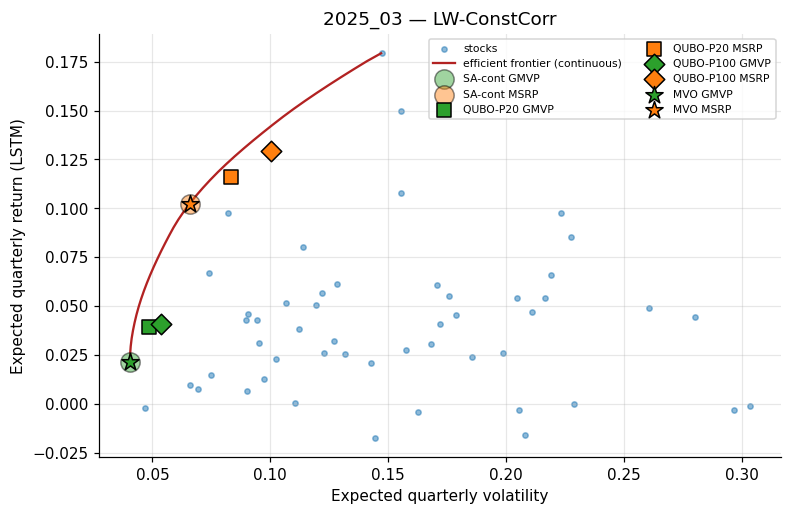

In [3]:
from pypfopt import EfficientFrontier
from qaportfolio import mvo
q = schedule[0].quarter
d = cfg["paths"]["results"] / q
mu = pd.read_csv(d / "mu.csv", dtype={"stock_id": str}).set_index("stock_id")["mu"]
cov = pd.read_csv(d / f"cov_{cfg['covariance']['primary']}.csv", index_col=0)
cov.index = cov.index.astype(str); cov.columns = cov.columns.astype(str)
cov = cov.loc[mu.index, mu.index]
W = pd.read_csv(d / "weights.csv", dtype={"stock_id": str}).set_index("stock_id")
from qaportfolio.covariance import ESTIMATOR_LABELS
lab = ESTIMATOR_LABELS[cfg["covariance"]["primary"]]

vols, rets = [], []
w_g = mvo.gmvp(mu, cov)
for r in np.linspace(float(mu @ w_g), mu.max() * 0.999, 40):
    ef = EfficientFrontier(mu, cov); ef.efficient_return(r)
    w = pd.Series(ef.clean_weights())
    vols.append(np.sqrt(w @ cov.values @ w)); rets.append(float(w @ mu))
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(np.sqrt(np.diag(cov)), mu, s=12, alpha=0.5, label="stocks")
ax.plot(vols, rets, color="firebrick", label="efficient frontier (continuous)")
markers = {"SA-cont": ("o", 160), "QUBO-P20": ("s", 90), "QUBO-P100": ("D", 90), "MVO": ("*", 140)}
for m, (mk, size) in markers.items():
    for port, color in [("GMVP", "tab:green"), ("MSRP", "tab:orange")]:
        w = W[f"{m}|{lab}|{port}"].reindex(mu.index).fillna(0)
        ax.scatter(np.sqrt(w @ cov.values @ w), w @ mu, marker=mk, s=size, color=color, edgecolor="k",
                   alpha=0.45 if m == "SA-cont" else 1.0, label=f"{m} {port}", zorder=3)
ax.set_xlabel("Expected quarterly volatility"); ax.set_ylabel("Expected quarterly return (LSTM)")
ax.legend(fontsize=7, ncol=2); ax.set_title(f"{q} — {lab}")

星號、半透明圓點、方塊、菱形分別代表 MVO、連續 SA、QUBO-P20、QUBO-P100（MVO 與連續 SA 幾乎重合）。所有點都以相同的事前 μ 與 Σ 評估：MVO 與連續 SA 落在效率前緣上，QUBO 解則落在前緣內側，也就是在相同風險下預期報酬較低，這就是「解的品質」差距的幾何意義。